# Análise Exploratória de Dados (EDA) - Risco de Crédito
**Datathon Fase 05 - Grupo 40**

Este notebook aborda as principais dores de negócio na concessão de crédito. Nosso objetivo é analisar os dados de propostas aceitas (`accepted.xlsx`) e rejeitadas (`rejected.xlsx`), extraindo insights sobre inadimplência, taxas de juros, DTI (Debt-to-Income) e Score de Risco.

**Diretrizes MLOps aplicadas aqui:**
* **Prevenção de SPOF e Vazamento de Dados (GAP 08):** O ambiente de Dev utiliza fallback sintético caso os dados reais não estejam cacheados localmente.
* **Alinhamento com Feature Engineering:** As transformações testadas aqui serão automatizadas no pipeline `dvc.yaml`.

In [1]:
# Instalação de dependências caso necessário
%pip install -q pandas numpy matplotlib seaborn missingno

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# Estilo visual dos gráficos
sns.set_theme(style="whitegrid", palette="muted")

## 1. Ingestão de Dados e Governança (Fallback Mode)
Carregando os dados respeitando a restrição de DVC. Se os dados brutos não estiverem no diretório, geramos dados sintéticos espelhando o schema oficial para não travar o desenvolvimento.

In [4]:
accepted_path = "../build/data/raw/accepted.xlsx"
rejected_path = "../build/data/raw/rejected.xlsx"

def load_or_mock_accepted():
    if os.path.exists(accepted_path):
        return pd.read_excel(accepted_path, nrows=10000)
    print("⚠️ accepted.xlsx não encontrado. Usando mock sintético baseado no schema real.")
    np.random.seed(42)
    n = 2000
    return pd.DataFrame({
        'loan_amnt': np.random.uniform(1000, 40000, n),
        'int_rate': np.random.uniform(5.0, 28.0, n),
        'grade': np.random.choice(['A', 'B', 'C', 'D', 'E', 'F', 'G'], n, p=[0.2, 0.25, 0.25, 0.15, 0.08, 0.05, 0.02]),
        'annual_inc': np.random.normal(70000, 20000, n),
        'dti': np.random.uniform(5.0, 40.0, n),
        'loan_status': np.random.choice(['Fully Paid', 'Charged Off', 'Current'], n, p=[0.65, 0.20, 0.15])
    })

def load_or_mock_rejected():
    if os.path.exists(rejected_path):
        return pd.read_excel(rejected_path, nrows=10000)
    print("⚠️ rejected.xlsx não encontrado. Usando mock sintético baseado no schema real.")
    n = 1000
    return pd.DataFrame({
        'Amount Requested': np.random.uniform(1000, 50000, n),
        'Risk_Score': np.random.normal(550, 100, n),
        'Debt-To-Income Ratio': [f"{np.random.randint(10, 100)}%" for _ in range(n)]
    })

df_acc = load_or_mock_accepted()
df_rej = load_or_mock_rejected()
print("\nDatasets carregados com sucesso!")


Datasets carregados com sucesso!


## 2. Qualidade e Consistência dos Dados
Antes de modelar, precisamos mapear dados faltantes que podem impactar a performance do LLM ou do classificador.

<Figure size 1200x400 with 0 Axes>

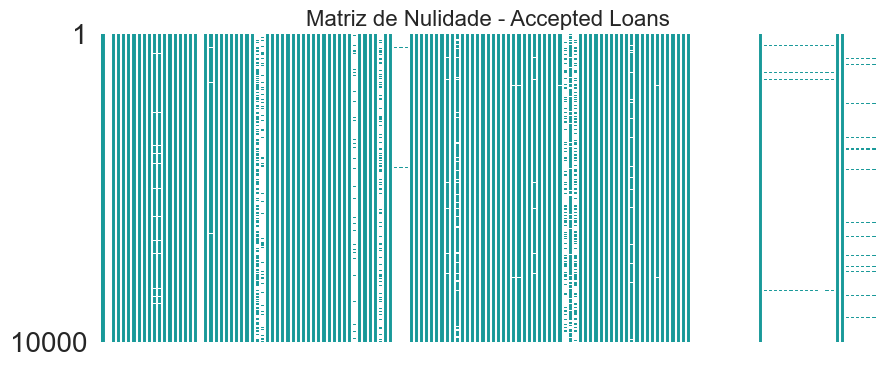

In [5]:
plt.figure(figsize=(12, 4))
msno.matrix(df_acc, sparkline=False, figsize=(10, 4), color=(0.1, 0.6, 0.6))
plt.title('Matriz de Nulidade - Accepted Loans', fontsize=16)
plt.show()

## 3. Respostas de Negócio (Business Pains)

### Dor 1: Qual é a real taxa de Inadimplência (Default)?
Para criar um modelo preditivo, precisamos focar nos contratos já encerrados. Empréstimos 'Current' serão filtrados no pipeline de features.

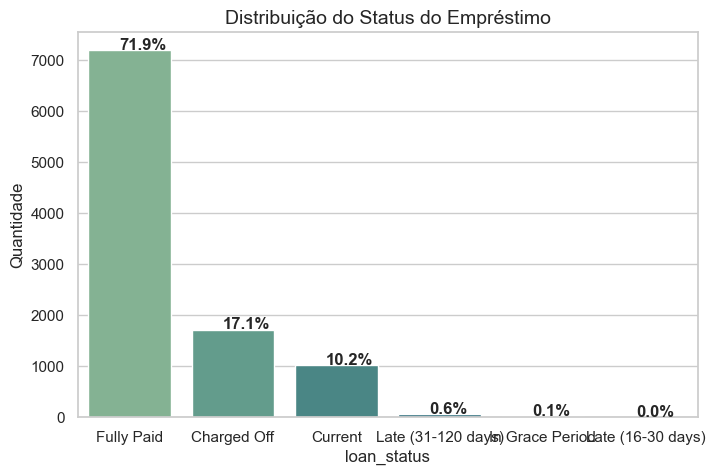

In [6]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_acc, x='loan_status', order=df_acc['loan_status'].value_counts().index, palette='crest')
plt.title('Distribuição do Status do Empréstimo', fontsize=14)
plt.ylabel('Quantidade')

# Adicionando % no gráfico
total = len(df_acc)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 10
    ax.annotate(percentage, (x, y), size=12, fontweight='bold')
plt.show()

### Dor 2: A classificação de risco (Grade) reflete corretamente a taxa de juros?
Investidores dependem das Grades (A-G) para equilibrar risco e retorno. Vamos validar se o sistema atual precifica o risco adequadamente.

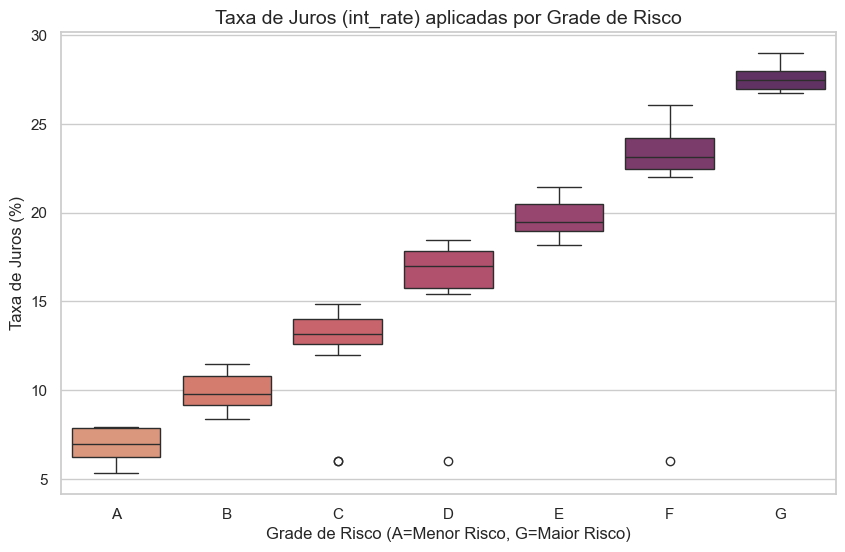

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_acc.sort_values('grade'), x='grade', y='int_rate', palette='flare')
plt.title('Taxa de Juros (int_rate) aplicadas por Grade de Risco', fontsize=14)
plt.xlabel('Grade de Risco (A=Menor Risco, G=Maior Risco)')
plt.ylabel('Taxa de Juros (%)')
plt.show()

**Insight de Negócio:** Há uma progressão linear clara. Modelos de IA devem ser penalizados (via LLM-as-a-judge) se recomendarem taxas incompatíveis com a grade estabelecida.

### Dor 3: Por que os clientes são rejeitados?
Avaliando o dataset de rejeitados para entender a barreira de entrada (Risk Score).

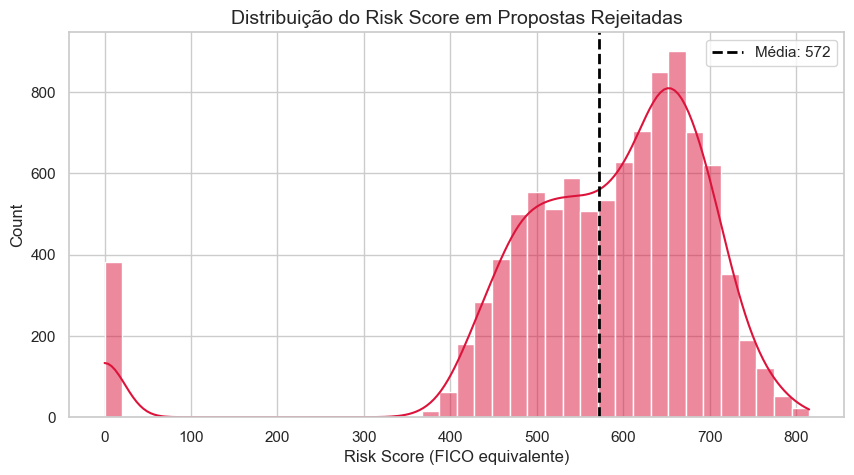

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df_rej['Risk_Score'].dropna(), bins=40, kde=True, color='crimson')
plt.axvline(df_rej['Risk_Score'].mean(), color='black', linestyle='dashed', linewidth=2, label=f'Média: {df_rej["Risk_Score"].mean():.0f}')
plt.title('Distribuição do Risk Score em Propostas Rejeitadas', fontsize=14)
plt.xlabel('Risk Score (FICO equivalente)')
plt.legend()
plt.show()

## 4. Matriz de Correlação (Evitando Data Leakage)
Buscando dependências fortes que podem viciar o nosso classificador *Random Forest*.

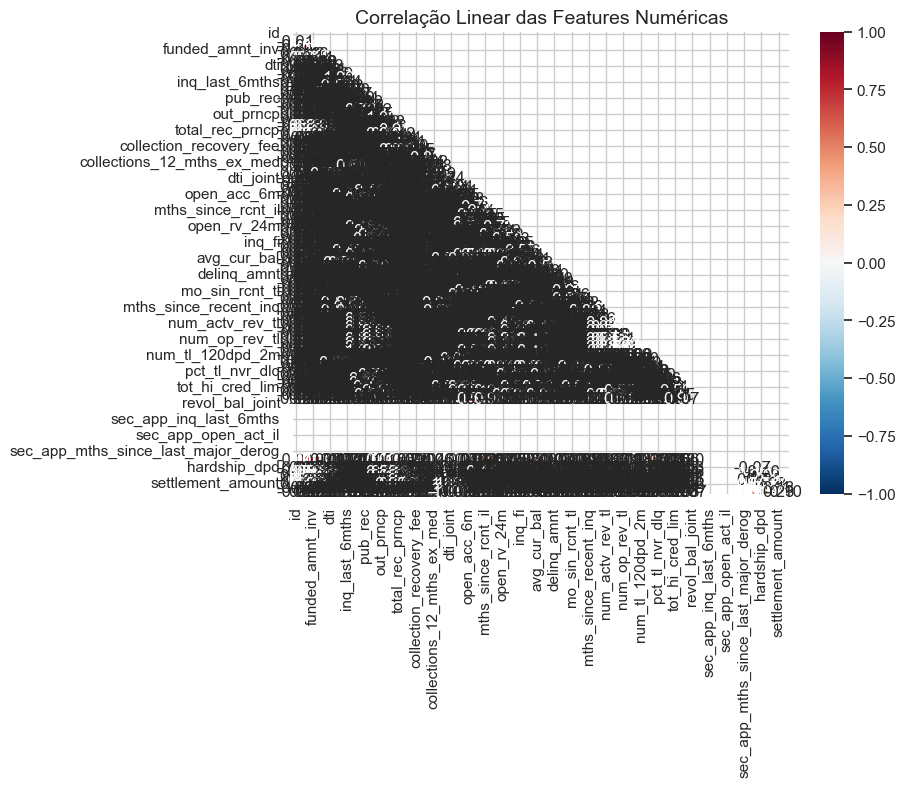

In [9]:
numeric_acc = df_acc.select_dtypes(include=[np.number])
corr = numeric_acc.corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlação Linear das Features Numéricas', fontsize=14)
plt.show()

# Conclusões e Plano de Ação para o Pipeline MLOps

1. **Engenharia de Features:** No script `feature_engineering.py`, devemos converter o `loan_status` ('Fully Paid' = 0, 'Charged Off' = 1) e descartar linhas 'Current'.
2. **Limpeza de Rejeitados:** A coluna `Debt-To-Income Ratio` do `rejected.xlsx` vem formatada como string com '%' (ex: '10%'). O pipeline precisa tratar isso convertendo para float antes de qualquer modelo.
3. **Monitoramento (Evidently):** O `dti` e a `int_rate` serão nossas variáveis chave para detecção de **Data Drift** ao longo do tempo.
4. **Segurança (LGPD):** O arquivo bruto original conteúm dados sensíveis indiretos. O `OutputGuardrail` (Presidio) na camada do Agente LLM garantirá que respostas sobre indivíduos específicos sejam anonimizadas.